# Model stylu jazdy — 3 klasy (eco / normal / aggressive)
Kanoniczny notebook. Etykiety nadawane regułami zakotwiczonymi w danych:

1. **aggressive** — zdarzenie kinematyczne (ostre hamowanie / przyspieszanie / gwałtowny gaz)
2. **eco** — niskie rzeczywiste zużycie paliwa w kontekście prędkości (poniżej p25)
3. **normal** — wszystko inne

`l_per_100km` (z narastającego licznika `fuel_cons`) służy **tylko do etykietowania eco** — nie jest cechą wejściową modelu. Model uczy się sterowalnej przez kierowcę części zużycia.

Model docelowy: `RandomForestClassifier`, eksport `emlearn` do ESP32.

In [12]:
import os
import glob
import json
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, balanced_accuracy_score)
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import emlearn

DATA_GLOB = "data/*.csv"
OUT_DIR   = "prepared_data"
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_ORDER = ["normal", "eco", "aggressive"]

WIN_SEC   = 5.0
STEP_SEC  = 2.5
TARGET_HZ = 10.0
WIN_N     = int(WIN_SEC  * TARGET_HZ)   # 50 samples = exactly 5s at 10Hz
STEP_N    = int(STEP_SEC * TARGET_HZ)   # 25 samples = exactly 2.5s at 10Hz


## 1. Wczytanie i czyszczenie danych
Resample do stałej siatki 10Hz (100ms) z `ffill` (CAN jest zdarzeniowy — sygnał trzyma ostatnią wartość do następnej ramki). Pochodne (`a`, `jerk`, `d_throttle`, `d_brake`) zerowane na granicach segmentów (przerwa > 150ms = silnik zgaszony / cofanie). `fuel_cons` (licznik narastający) również `ffill`.

In [13]:
def load_one_csv(path):
    df = pd.read_csv(path)

    needed = ["timestamp", "ignition", "speed", "rpm", "throttle", "brake", "rear_gear"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {path}: {missing}")

    for c in needed:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    if "fuel_cons" in df.columns:
        df["fuel_cons"] = pd.to_numeric(df["fuel_cons"], errors="coerce")

    df = df.dropna(subset=needed).copy()
    df = df.sort_values("timestamp")
    df = df.drop_duplicates(subset=["timestamp"], keep="first")

    # Resample to fixed 10Hz grid before filtering
    t_start = int(df["timestamp"].iloc[0] // 100) * 100
    t_end   = int(df["timestamp"].iloc[-1] // 100) * 100
    grid = np.arange(t_start, t_end + 100, 100, dtype=np.int64)

    df = df.set_index("timestamp")
    df = df.reindex(df.index.union(grid)).sort_index()

    for col in ["speed", "rpm", "throttle", "brake", "ignition", "rear_gear"]:
        df[col] = df[col].ffill().fillna(0)
    if "fuel_cons" in df.columns:
        df["fuel_cons"] = df["fuel_cons"].ffill()  # cumulative counter -> hold last value

    df = df.reindex(grid).reset_index().rename(columns={"index": "timestamp"})

    df = df[(df["ignition"] == 1) & (df["rear_gear"] == 0) & (df["speed"] >= 0)].copy()
    if df.empty:
        return df

    df = df.reset_index(drop=True)
    DT = 0.1
    boundary = (df["timestamp"].diff() > 150).fillna(True)

    df["dt"] = DT
    df["a_ms2"] = (df["speed"].diff() / 3.6) / DT
    df["a_ms2"] = df["a_ms2"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "a_ms2"] = 0.0

    df["jerk_ms3"] = df["a_ms2"].diff() / DT
    df["jerk_ms3"] = df["jerk_ms3"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "jerk_ms3"] = 0.0

    df["d_throttle_s"] = df["throttle"].diff() / DT
    df["d_throttle_s"] = df["d_throttle_s"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "d_throttle_s"] = 0.0

    df["d_brake_s"] = df["brake"].diff() / DT
    df["d_brake_s"] = df["d_brake_s"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "d_brake_s"] = 0.0

    df["source_file"] = os.path.basename(path)
    return df.reset_index(drop=True)

files   = sorted(glob.glob(DATA_GLOB))
trips   = [load_one_csv(p) for p in files]
raw_all = pd.concat(trips, ignore_index=True)

print("Liczba plikow:", len(files))
print("Liczba wierszy po czyszczeniu:", len(raw_all))
print(f"fuel_cons dostepnosc: {raw_all['fuel_cons'].notna().mean():.1%}")
raw_all.head()


Liczba plikow: 45
Liczba wierszy po czyszczeniu: 680445
fuel_cons dostepnosc: 100.0%


,timestamp,ignition,speed,rpm,throttle,brake,fuel_level,fuel_cons,distance,range,oil_temp,esp,rear_gear,dt,a_ms2,jerk_ms3,d_throttle_s,d_brake_s,source_file
0,97400,1.0,0.0,0.0,0.0,0.0,NaN,0.00,NaN,NaN,NaN,NaN,0.0,0.1,0.0,0.0,0.0,0.0,20260404_091932.csv
1,97500,1.0,0.0,0.0,0.0,1.0,NaN,0.00,NaN,NaN,NaN,NaN,0.0,0.1,0.0,0.0,0.0,10.0,20260404_091932.csv
2,128400,1.0,0.0,1369.0,0.0,0.0,NaN,6.13,NaN,NaN,NaN,NaN,0.0,0.1,0.0,0.0,0.0,0.0,20260404_091932.csv
3,128500,1.0,0.0,1369.0,0.0,0.0,NaN,6.13,NaN,NaN,NaN,NaN,0.0,0.1,0.0,0.0,0.0,0.0,20260404_091932.csv
4,128600,1.0,0.0,1368.0,0.0,0.0,NaN,7.15,NaN,NaN,NaN,NaN,0.0,0.1,0.0,0.0,0.0,0.0,20260404_091932.csv


## 2. Okna czasowe + zużycie paliwa
Okna 5s, krok 2.5s (~50% overlap). Dla każdego okna liczymy `l_per_100km` z różnicy licznika paliwa i przejechanego dystansu:

```
fuel_diff [mL] = fuel_cons[-1] - fuel_cons[0]
dist_km        = sum(speed_kmh) / 3.6 * 0.1 / 1000
l_per_100km    = fuel_diff / (10 * dist_km)
```


In [14]:
def make_window_features(df, win_n=WIN_N, step_n=STEP_N):
    rows = []
    if len(df) < win_n:
        return pd.DataFrame()

    has_fuel = "fuel_cons" in df.columns

    for start in range(0, len(df) - win_n + 1, step_n):
        w = df.iloc[start:start + win_n]

        # Skip near-stop windows — handled as "normal" directly in MCU firmware
        if w["speed"].mean() < 2.0:
            continue

        feat = {
            "source_file":   w["source_file"].iloc[-1],
            "ts_end":        int(w["timestamp"].iloc[-1]),

            "speed_mean":    w["speed"].mean(),
            "speed_std":     w["speed"].std(ddof=0),
            "speed_p95":     np.percentile(w["speed"], 95),

            "rpm_mean":      w["rpm"].mean(),
            "rpm_std":       w["rpm"].std(ddof=0),
            "rpm_p95":       np.percentile(w["rpm"], 95),

            "throttle_mean": w["throttle"].mean(),
            "throttle_std":  w["throttle"].std(ddof=0),
            "throttle_p95":  np.percentile(w["throttle"], 95),
            "throttle_dp95": np.percentile(w["d_throttle_s"], 95),

            "brake_mean":    w["brake"].mean(),
            "brake_p95":     np.percentile(w["brake"], 95),
            "brake_dp95":    np.percentile(w["d_brake_s"], 95),

            "a_mean":        w["a_ms2"].mean(),
            "a_std":         w["a_ms2"].std(ddof=0),
            "a_p95":         np.percentile(w["a_ms2"], 95),
            "a_p05":         np.percentile(w["a_ms2"], 5),
            "abs_a_mean":    np.abs(w["a_ms2"]).mean(),

            "jerk_abs_mean": np.abs(w["jerk_ms3"]).mean(),
            "jerk_abs_p95":  np.percentile(np.abs(w["jerk_ms3"]), 95),
        }

        # Fuel consumption — label source only, NOT a model feature
        l100 = np.nan
        if has_fuel:
            fc = w["fuel_cons"].dropna()
            if len(fc) >= 2:
                fuel_diff = fc.iloc[-1] - fc.iloc[0]
                dist_km   = w["speed"].sum() / 3.6 * 0.1 / 1000
                if dist_km > 0.05 and fuel_diff >= 0:
                    l100 = fuel_diff / (10.0 * dist_km)
        feat["l_per_100km"] = l100

        rows.append(feat)

    return pd.DataFrame(rows)

windows = []
for t in trips:
    wf = make_window_features(t)
    if len(wf):
        windows.append(wf)

feat_df = pd.concat(windows, ignore_index=True)
print("Liczba okien:", len(feat_df))
print(f"Okna z l_per_100km: {feat_df['l_per_100km'].notna().mean():.1%}")
feat_df.head()


Liczba okien: 24941
Okna z l_per_100km: 77.6%


,source_file,ts_end,speed_mean,speed_std,speed_p95,rpm_mean,rpm_std,rpm_p95,throttle_mean,throttle_std,...,brake_p95,brake_dp95,a_mean,a_std,a_p95,a_p05,abs_a_mean,jerk_abs_mean,jerk_abs_p95,l_per_100km
0,20260404_091932.csv,137800,2.00,3.200000,8.00,1215.90,264.593216,1368.55,1.66,6.192286,...,0.0,0.0,0.444444,1.401058,2.777778,0.000000,0.444444,5.555556,27.777778,NaN
1,20260404_091932.csv,140300,6.94,3.971952,12.00,1304.04,159.428349,1594.00,22.74,25.543539,...,0.0,0.0,0.666667,1.625415,2.777778,0.000000,0.777778,12.222222,43.055556,NaN
2,20260404_091932.csv,142800,11.82,2.355334,15.55,1281.12,191.020380,1594.00,40.60,20.632014,...,0.0,0.0,0.444444,1.160034,2.777778,0.000000,0.555556,11.111111,27.777778,NaN
3,20260404_091932.csv,145300,15.06,1.678213,17.00,1200.60,105.997358,1310.10,25.00,23.583045,...,0.0,0.0,0.166667,1.166667,2.777778,-1.527778,0.500000,10.000000,27.777778,NaN
4,20260404_091932.csv,147800,15.08,1.481081,17.00,1168.34,97.832430,1307.65,5.48,14.337699,...,13.1,42.0,-0.166667,1.025899,0.000000,-2.777778,0.388889,7.777778,27.777778,NaN


## 3. Etykiety (3 klasy) + margines

Kolejność sprawdzania — **pierwsza pasująca wygrywa**:

**1. aggressive** (OR — dowolne zdarzenie kinematyczne; progi na ~p95, żeby łapać tylko faktycznie ostre zdarzenia, a nie umiarkowaną jazdę):
- `a_p05 < -5.0` — ostre hamowanie (≥2 km/h spadku na 100ms)
- `abs_a_mean > 1.10` — utrzymana silna dynamika (p95)
- `throttle_dp95 > 150` — mocny "kop" gazu (p95)
- `brake_p95 > 180` — firm hamowanie pedałem (p95 realnych hamowań)

**2. eco** — `l_per_100km` **poniżej p25** dla swojego zakresu prędkości (miasto <50 / trasa 50–90 / autostrada >90).

**3. normal** — `l_per_100km` **powyżej p50**, albo brak wiarygodnego paliwa (wolna/jałowa jazda).

**Margines (p25–p50) — odrzucany z treningu.** Okna o zużyciu między progiem eco a medianą są niejednoznaczne: w cechach wyglądają jak eco, ale palą więcej. To one powodowały mylenie normal↔eco. Usuwamy je, żeby granica decyzyjna była ostra. Model i tak klasyfikuje je w inferencji — ale nie uczy się na szumie.

In [15]:
# --- Eco/normal thresholds per speed bin (reliable windows only) ---
# Margin: eco = below p25, normal = above p50. The fuzzy band p25-p50 is dropped
# from training — those windows are ambiguous (look eco in features but consume more),
# which is exactly what caused normal->eco confusion.
SPEED_BINS   = [0, 50, 90, 200]
SPEED_LABELS = ["miasto", "trasa", "autostrada"]

reliable = feat_df.dropna(subset=["l_per_100km"]).copy()
reliable = reliable[(reliable["speed_mean"] >= 10) & (reliable["l_per_100km"] <= 40)]
reliable["speed_bin"] = pd.cut(reliable["speed_mean"], bins=SPEED_BINS, labels=SPEED_LABELS)

ECO_THRESH   = reliable.groupby("speed_bin", observed=True)["l_per_100km"].quantile(0.25).to_dict()
NORMAL_FLOOR = reliable.groupby("speed_bin", observed=True)["l_per_100km"].quantile(0.50).to_dict()
print("Progi wg prędkości (eco < p25 | margines p25-p50 odrzucany | normal > p50):")
for k in SPEED_LABELS:
    print(f"  {k:11s}: eco < {ECO_THRESH[k]:.2f}  |  normal > {NORMAL_FLOOR[k]:.2f}  L/100km")


def speed_bin_of(speed):
    if speed < 50:
        return "miasto"
    elif speed < 90:
        return "trasa"
    return "autostrada"


def assign_label(row):
    # 1. aggressive — kinematic OR-event (no fuel needed). Thresholds at ~p95 so that
    #    only genuinely hard events count (moderate accel / light braking stay normal).
    # Note: no raw speed threshold here — steady high-speed cruising is not, by
    # itself, aggressive driving; only sharp kinematic events count.
    if (row["a_p05"] < -5.5              # hard braking: 2+ km/h decel per 100ms
            or row["abs_a_mean"] > 1.20      # sustained strong dynamics (p95)
            or row["throttle_dp95"] > 150.0  # hard throttle stab (p95)
            or row["brake_p95"] > 230.0):    # firm brake pressure (p95 of real braking)
        return "aggressive"

    # 2/3. eco vs normal — by fuel in speed context, with a dropped margin band
    l = row["l_per_100km"]
    if pd.notna(l) and row["speed_mean"] >= 10 and l <= 40:
        b = speed_bin_of(row["speed_mean"])
        if l < ECO_THRESH[b]:
            return "eco"
        if l > NORMAL_FLOOR[b]:
            return "normal"
        return None  # fuzzy margin p25-p50 -> drop from training

    # No reliable fuel and not aggressive -> normal (real slow/idle driving)
    return "normal"


feat_df["label"] = feat_df.apply(assign_label, axis=1)
n_dropped = feat_df["label"].isna().sum()
labeled = feat_df.dropna(subset=["label"]).copy()

print(f"\nOdrzucono okien z marginesu p25-p50: {n_dropped}")
print("=== Rozkład etykiet ===")
print(labeled["label"].value_counts())
print((labeled["label"].value_counts(normalize=True) * 100).round(1).astype(str) + " %")

feature_cols = [c for c in labeled.columns
                if c not in ["source_file", "ts_end", "label", "l_per_100km"]]
X      = labeled[feature_cols].copy()
y      = labeled["label"].copy()
groups = labeled["source_file"].copy()

split = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(split.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

quantizer = MinMaxScaler(feature_range=(-30000, 30000), clip=True)
X_train_q = np.rint(quantizer.fit_transform(X_train)).astype(np.int16)
X_test_q  = np.rint(quantizer.transform(X_test)).astype(np.int16)
print(f"\nTrain: {len(X_train)}  Test: {len(X_test)}  Cechy: {len(feature_cols)}")


Progi wg prędkości (eco < p25 | margines p25-p50 odrzucany | normal > p50):
  miasto     : eco < 2.96  |  normal > 5.89  L/100km
  trasa      : eco < 3.28  |  normal > 5.30  L/100km
  autostrada : eco < 5.93  |  normal > 7.99  L/100km

Odrzucono okien z marginesu p25-p50: 4714
=== Rozkład etykiet ===
label
normal        13578
eco            4556
aggressive     2093
Name: count, dtype: int64
label
normal        67.1 %
eco           22.5 %
aggressive    10.3 %
Name: proportion, dtype: str

Train: 13259  Test: 6968  Cechy: 20


## 4. Walidacja etykiet — zużycie paliwa per klasa
Sprawdzamy, czy etykiety trzymają się fizyki: okna `eco` powinny mieć **najniższe** rzeczywiste L/100km, a `aggressive` **najwyższe**. Jeśli tak — reguły są sensowne.

=== l_per_100km wg klasy (tylko okna z wiarygodnym paliwem) ===
             count  mean   std  min   25%   50%    75%    max
label                                                        
aggressive  1082.0  9.77  7.58  0.0  3.76  8.39  13.80  39.65
eco         4556.0  2.79  1.87  0.0  1.30  2.67   4.54   5.93
normal      8996.0  9.61  2.75  5.3  8.03  9.32  10.89  27.98


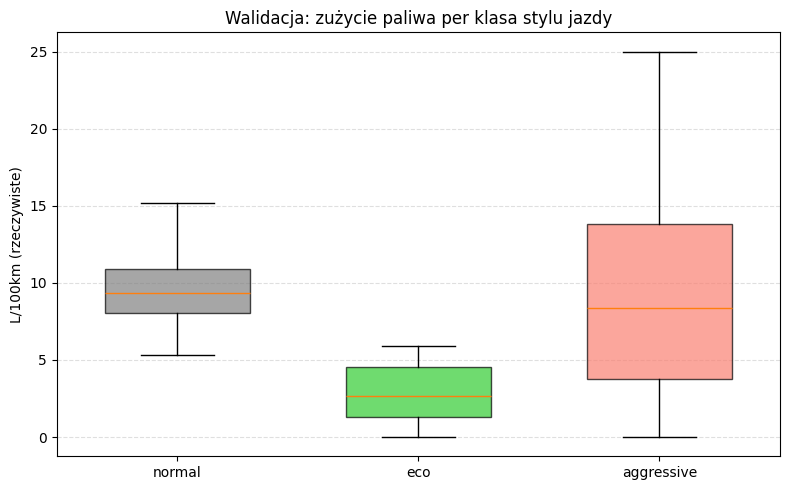

In [16]:
val = feat_df.dropna(subset=["l_per_100km"]).copy()
val = val[val["l_per_100km"] <= 40]

print("=== l_per_100km wg klasy (tylko okna z wiarygodnym paliwem) ===")
print(val.groupby("label")["l_per_100km"]
      .describe(percentiles=[.25, .5, .75]).round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
order  = [c for c in CLASS_ORDER if c in val["label"].unique()]
data   = [val.loc[val["label"] == c, "l_per_100km"].clip(0, 25) for c in order]
colors = {"normal": "gray", "eco": "limegreen", "aggressive": "salmon"}
bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.6, tick_labels=order)
for patch, c in zip(bp["boxes"], order):
    patch.set_facecolor(colors[c]); patch.set_alpha(0.7)
ax.set_ylabel("L/100km (rzeczywiste)")
ax.set_title("Walidacja: zużycie paliwa per klasa stylu jazdy")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## 5. Trening modelu
`RandomForestClassifier` (wygrał porównanie na zadaniu paliwowym — stabilniejszy i lepszy CV). Parametry ograniczone pod ESP32: `n_estimators=60`, `max_depth=7`.

In [17]:
COMMON = dict(
    n_estimators=60,
    max_depth=7,
    min_samples_leaf=12,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)

model = RandomForestClassifier(**COMMON)
model.fit(X_train_q, y_train)
y_pred = model.predict(X_test_q)

print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 4))
print("Macro F1:", round(f1_score(y_test, y_pred, average="macro"), 4))
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix [normal, eco, aggressive]:")
print(confusion_matrix(y_test, y_pred, labels=CLASS_ORDER))


Balanced accuracy: 0.9611
Macro F1: 0.9405
              precision    recall  f1-score   support

  aggressive     0.9504    0.9894    0.9695       756
         eco     0.8344    0.9805    0.9016      1799
      normal     0.9909    0.9132    0.9505      4413

    accuracy                         0.9389      6968
   macro avg     0.9253    0.9611    0.9405      6968
weighted avg     0.9461    0.9389    0.9399      6968

Confusion matrix [normal, eco, aggressive]:
[[4030  347   36]
 [  32 1764    3]
 [   5    3  748]]


## 6. Cross-walidacja (GroupKFold) — ExtraTrees vs RandomForest
5 foldów, każdy z innymi plikami (trasami). Porównujemy oba modele dla pewności wyboru.

In [18]:
gkf = GroupKFold(n_splits=5)

for name, ModelClass in [("ExtraTrees", ExtraTreesClassifier),
                          ("RandomForest", RandomForestClassifier)]:
    cv_ba, cv_f1 = [], []
    for tr_idx, va_idx in gkf.split(X, y, groups=groups):
        sc  = MinMaxScaler(feature_range=(-30000, 30000), clip=True)
        Xtr = np.rint(sc.fit_transform(X.iloc[tr_idx])).astype(np.int16)
        Xva = np.rint(sc.transform(X.iloc[va_idx])).astype(np.int16)
        m   = ModelClass(**COMMON)
        m.fit(Xtr, y.iloc[tr_idx])
        yp  = m.predict(Xva)
        cv_ba.append(balanced_accuracy_score(y.iloc[va_idx], yp))
        cv_f1.append(f1_score(y.iloc[va_idx], yp, average="macro"))
    print(f"{name:13s} | balanced_acc {np.mean(cv_ba):.4f} ± {np.std(cv_ba):.4f}"
          f" | macro_F1 {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}")


ExtraTrees    | balanced_acc 0.8732 ± 0.0334 | macro_F1 0.7972 ± 0.0203
RandomForest  | balanced_acc 0.9578 ± 0.0118 | macro_F1 0.9414 ± 0.0091


## 7. Macierz pomyłek — wizualizacja
Lewa: liczby. Prawa: znormalizowana wierszowo (recall per klasa).

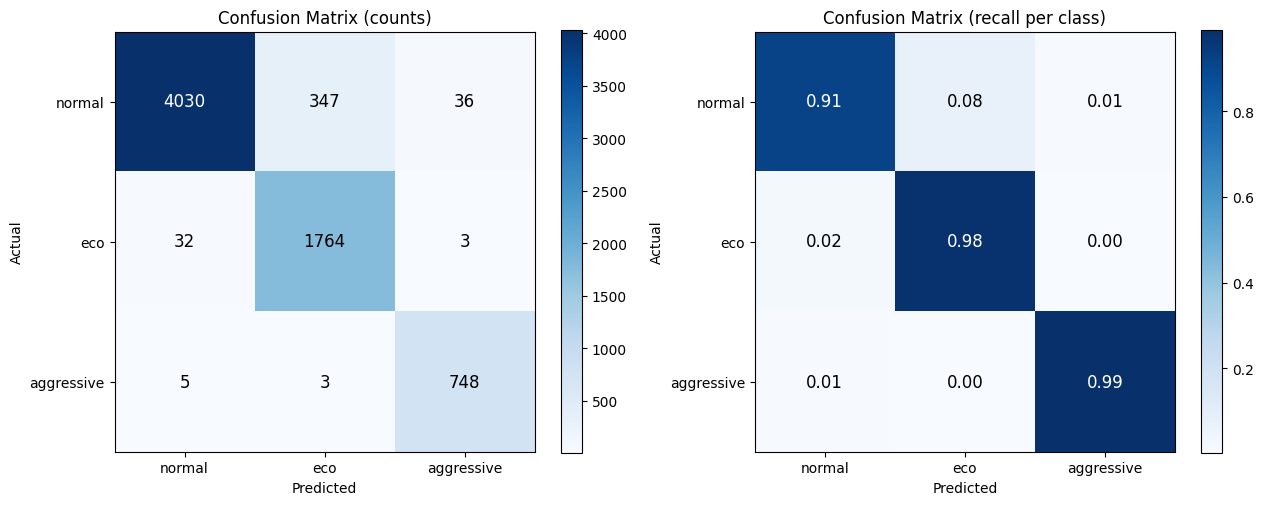

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], [".0f", ".2f"],
    ["Confusion Matrix (counts)", "Confusion Matrix (recall per class)"]
):
    im = ax.imshow(data, cmap="Blues")
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_yticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels(CLASS_ORDER)
    ax.set_yticklabels(CLASS_ORDER)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(len(CLASS_ORDER)):
        for j in range(len(CLASS_ORDER)):
            ax.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                    fontsize=12, color="white" if data[i, j] > data.max() * 0.5 else "black")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


## 8. Eksport do ESP32
Model + metadane kwantyzacji do `prepared_data/`. Pliki nazwane `driving_style_*` żeby nie nadpisać artefaktów ze starego notebooka.

In [20]:
feat_df.to_csv(os.path.join(OUT_DIR, "driving_style_windows_labeled.csv"), index=False)

fi = pd.DataFrame({"feature": feature_cols, "importance": model.feature_importances_}) \
       .sort_values("importance", ascending=False)
fi.to_csv(os.path.join(OUT_DIR, "driving_style_feature_importance.csv"), index=False)
print("Top 10 cech:")
print(fi.head(10).to_string(index=False))

cmodel = emlearn.convert(model, method="inline", dtype="int16_t", leaf_bits=6)
cmodel.save(file=os.path.join(OUT_DIR, "driving_style_model.h"), name="driving_style_model")

q_meta = {
    "feature_order": feature_cols,
    "scale": quantizer.scale_.tolist(),
    "min":   quantizer.min_.tolist(),
    "class_order": CLASS_ORDER,
}
with open(os.path.join(OUT_DIR, "driving_style_quantizer.json"), "w", encoding="utf-8") as f:
    json.dump(q_meta, f, indent=2)

print("\nZapisano driving_style_model.h i driving_style_quantizer.json")


Top 10 cech:
      feature  importance
throttle_dp95    0.195575
throttle_mean    0.095599
   speed_mean    0.091531
       a_mean    0.085447
   abs_a_mean    0.084034
    speed_p95    0.052738
        a_std    0.048888
 throttle_p95    0.045489
      rpm_std    0.042599
jerk_abs_mean    0.039622

Zapisano driving_style_model.h i driving_style_quantizer.json


## 9. Wizualizacja etykiet na przebiegu przejazdu

Nakładamy nadane etykiety (`eco` / `normal` / `aggressive`) na surowe sygnały CAN (prędkość, gaz, hamulec) w czasie dla wybranego pliku. Pozwala wzrokowo zweryfikować, czy reguły łapią zamierzone momenty. Pas marginesu (p25–p50, odrzucony z treningu) zaznaczony osobnym kolorem.

In [21]:
# Interactive plot (Plotly) — zoom / pan / box-zoom, toggle series via legend.
# pip install plotly  (if missing)
import plotly.graph_objects as go

# Pick a trip to visualise (change index to inspect other files)
sample_file = feat_df["source_file"].unique()[19]

df_raw    = raw_all[raw_all["source_file"] == sample_file].copy()
df_labels = feat_df[feat_df["source_file"] == sample_file].copy().sort_values("ts_end")

t0 = df_raw["timestamp"].min()
df_raw["time_s"]    = (df_raw["timestamp"] - t0) / 1000.0
df_labels["time_s"] = (df_labels["ts_end"] - t0) / 1000.0

MAX_TIME = 10000.0
df_raw    = df_raw[df_raw["time_s"] <= MAX_TIME]
df_labels = df_labels[df_labels["time_s"] <= MAX_TIME]

# Pedals to 0-100% (throttle 0-255, brake 0-1023)
df_raw["throttle_pct"] = df_raw["throttle"] / 2.55
df_raw["brake_pct"]    = df_raw["brake"] / 10.23

color_map = {"normal": "gray", "eco": "limegreen", "aggressive": "salmon", "margines": "gold"}

# Merge consecutive windows with the same label into single bands (few shapes -> fast)
bands = []
cur_lbl, cur_start, cur_end = None, None, None
for _, row in df_labels.iterrows():
    lbl   = row["label"] if pd.notna(row["label"]) else "margines"
    start = max(0.0, row["time_s"] - WIN_SEC)
    end   = row["time_s"]
    if lbl == cur_lbl and start <= cur_end:      # same label and overlapping -> extend
        cur_end = end
    else:
        if cur_lbl is not None:
            bands.append((cur_lbl, cur_start, cur_end))
        cur_lbl, cur_start, cur_end = lbl, start, end
if cur_lbl is not None:
    bands.append((cur_lbl, cur_start, cur_end))

fig = go.Figure()

# Label background bands
for lbl, x0, x1 in bands:
    fig.add_vrect(x0=x0, x1=x1, fillcolor=color_map.get(lbl, "white"),
                  opacity=0.18, line_width=0, layer="below")

# Raw signals
fig.add_trace(go.Scatter(x=df_raw["time_s"], y=df_raw["speed"],
                         name="Prędkość [km/h]", line=dict(color="blue", width=1)))
fig.add_trace(go.Scatter(x=df_raw["time_s"], y=df_raw["throttle_pct"],
                         name="Gaz [%]", line=dict(color="green", width=1)))
fig.add_trace(go.Scatter(x=df_raw["time_s"], y=df_raw["brake_pct"],
                         name="Hamulec [%]", line=dict(color="red", width=1)))
# RPM on a secondary y-axis (much larger scale than speed/pedals)
fig.add_trace(go.Scatter(x=df_raw["time_s"], y=df_raw["rpm"],
                         name="Obroty [RPM]", line=dict(color="purple", width=1),
                         yaxis="y2"))

# Dummy traces so the label colors appear in the legend
for lbl, col in color_map.items():
    fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
                             marker=dict(size=12, color=col, opacity=0.5),
                             name=f"Styl: {lbl}"))

fig.update_layout(
    title=f"Sygnały CAN nałożone na styl jazdy — {sample_file}",
    xaxis_title="Czas przejazdu [s]",
    yaxis_title="Wartość parametru",
    yaxis2=dict(title="Obroty [RPM]", overlaying="y", side="right",
                showgrid=False, rangemode="tozero"),
    height=600,
    hovermode="x unified",
    dragmode="pan",          # drag = pan; scroll wheel = zoom
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.update_xaxes(rangeslider=dict(visible=True))   # mini-overview slider at the bottom

fig.show(config={"scrollZoom": True})


## 9b. Predykcje modelu na tym samym przejeździe

Ten sam wykres co wyżej, ale pasy tła pokazują teraz to, co faktycznie przewidział wytrenowany `RandomForestClassifier` (na skwantyzowanych cechach — ta sama ścieżka co na ESP32), a **nie** regułę etykietowania z sekcji 3. Pozwala porównać regułę z modelem na tym samym fragmencie jazdy i sprawdzić, czy ten przejazd był w zbiorze testowym (model go nie widział w treningu).

In [23]:
# Predict on the same windows shown in section 9 (df_labels already filtered
# to sample_file, sorted, time-clipped to MAX_TIME) — reuses model/quantizer
# from training, exact same feature order and quantization as the ESP32 path.
X_pred = df_labels[feature_cols]
X_pred_q = np.rint(quantizer.transform(X_pred)).astype(np.int16)
df_labels["pred_label"] = model.predict(X_pred_q)

test_files = set(groups.iloc[test_idx])
split_note = "TEST (model nie widzial tego przejazdu w treningu)" if sample_file in test_files \
             else "TRAIN (model uczyl sie na tym przejezdzie)"
print(f"{sample_file}: {split_note}")

# Merge consecutive windows with the same predicted label into bands (same
# logic as section 9, but no "margines" case — model.predict always returns
# one of the 3 classes).
pred_bands = []
cur_lbl, cur_start, cur_end = None, None, None
for _, row in df_labels.iterrows():
    lbl   = row["pred_label"]
    start = max(0.0, row["time_s"] - WIN_SEC)
    end   = row["time_s"]
    if lbl == cur_lbl and start <= cur_end:
        cur_end = end
    else:
        if cur_lbl is not None:
            pred_bands.append((cur_lbl, cur_start, cur_end))
        cur_lbl, cur_start, cur_end = lbl, start, end
if cur_lbl is not None:
    pred_bands.append((cur_lbl, cur_start, cur_end))

fig_pred = go.Figure()

for lbl, x0, x1 in pred_bands:
    fig_pred.add_vrect(x0=x0, x1=x1, fillcolor=color_map.get(lbl, "white"),
                        opacity=0.18, line_width=0, layer="below")

fig_pred.add_trace(go.Scatter(x=df_raw["time_s"], y=df_raw["speed"],
                              name="Predkosc [km/h]", line=dict(color="blue", width=1)))
fig_pred.add_trace(go.Scatter(x=df_raw["time_s"], y=df_raw["throttle_pct"],
                              name="Gaz [%]", line=dict(color="green", width=1)))
fig_pred.add_trace(go.Scatter(x=df_raw["time_s"], y=df_raw["brake_pct"],
                              name="Hamulec [%]", line=dict(color="red", width=1)))
fig_pred.add_trace(go.Scatter(x=df_raw["time_s"], y=df_raw["rpm"],
                              name="Obroty [RPM]", line=dict(color="purple", width=1),
                              yaxis="y2"))

for lbl in ["normal", "eco", "aggressive"]:
    fig_pred.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
                                  marker=dict(size=12, color=color_map[lbl], opacity=0.5),
                                  name=f"Model: {lbl}"))

fig_pred.update_layout(
    title=f"Predykcje modelu (nie regula) — {sample_file}",
    xaxis_title="Czas przejazdu [s]",
    yaxis_title="Wartosc parametru",
    yaxis2=dict(title="Obroty [RPM]", overlaying="y", side="right",
                showgrid=False, rangemode="tozero"),
    height=600,
    hovermode="x unified",
    dragmode="pan",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig_pred.update_xaxes(rangeslider=dict(visible=True))

fig_pred.show(config={"scrollZoom": True})


20260412_134432.csv: TEST (model nie widzial tego przejazdu w treningu)


## 10. Wpływ cech na klasę — co generuje eco / agresję

Dwie perspektywy:
- **Lewy wykres** — globalna ważność cech wg modelu (feature_importances_).
- **Prawy wykres (sygnatura klasy)** — dla każdej klasy: o ile średnia cechy odbiega od średniej ogólnej (z-score). Czerwony = podwyższona, niebieski = obniżona.

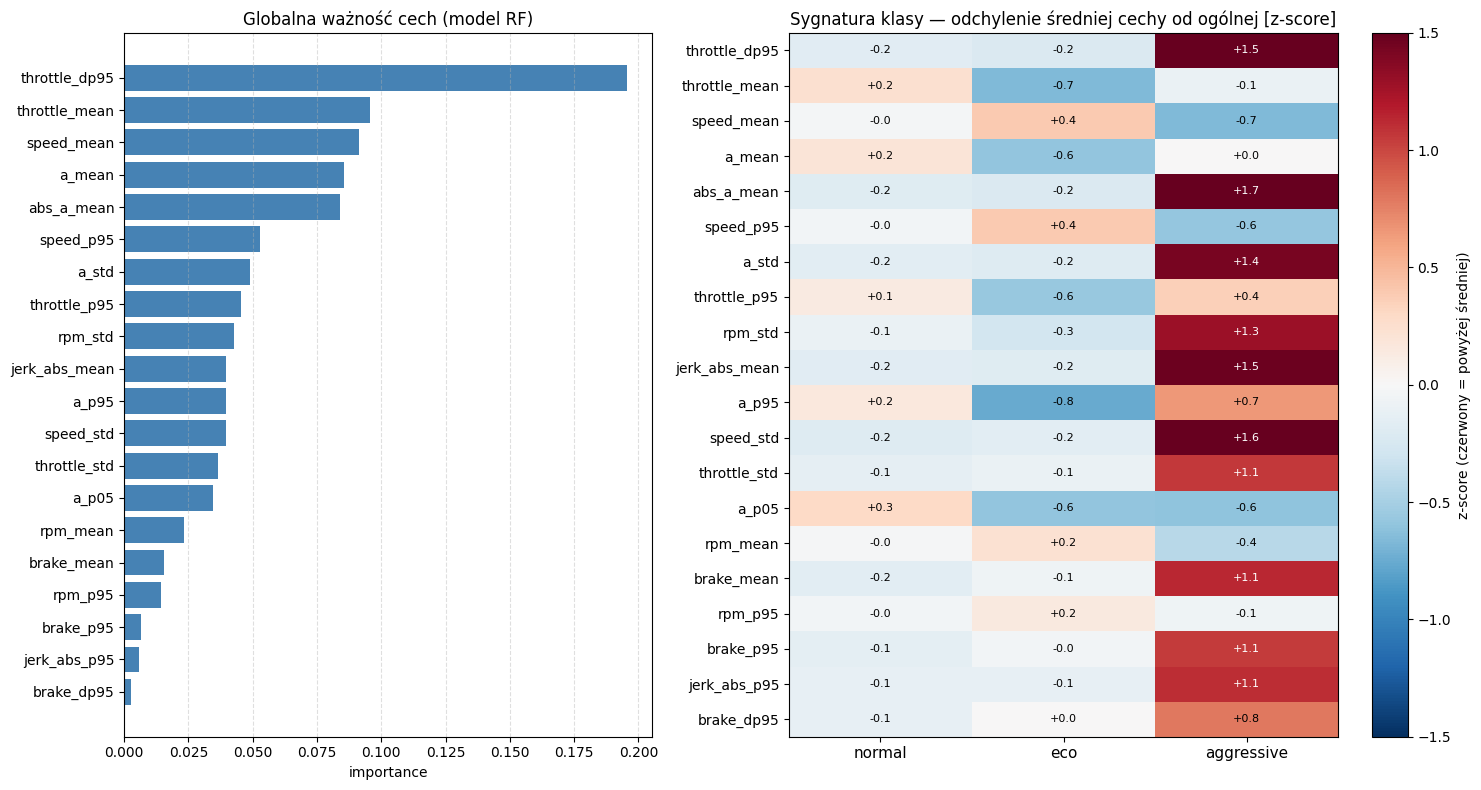

=== Co charakteryzuje każdą klasę (z-score) ===

NORMAL
  podwyższone: a_p05 (+0.3), throttle_mean (+0.2), a_mean (+0.2)
  obniżone:    speed_std (-0.2), abs_a_mean (-0.2), throttle_dp95 (-0.2)

ECO
  podwyższone: speed_p95 (+0.4), speed_mean (+0.4), rpm_mean (+0.2)
  obniżone:    a_p95 (-0.8), throttle_mean (-0.7), a_p05 (-0.6)

AGGRESSIVE
  podwyższone: abs_a_mean (+1.7), speed_std (+1.6), throttle_dp95 (+1.5)
  obniżone:    speed_mean (-0.7), a_p05 (-0.6), speed_p95 (-0.6)


In [22]:
import matplotlib.pyplot as plt

imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
feat_ord = imp.index.tolist()

Xf     = labeled[feature_cols].astype(float)
g_mean = Xf.mean()
g_std  = Xf.std(ddof=0).replace(0, 1.0)
sig = pd.DataFrame({c: (Xf[labeled["label"] == c].mean() - g_mean) / g_std
                    for c in CLASS_ORDER})[CLASS_ORDER].loc[feat_ord]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={"width_ratios": [1, 1.3]})
axL.barh(feat_ord[::-1], imp.loc[feat_ord][::-1].values, color="steelblue")
axL.set_title("Globalna ważność cech (model RF)")
axL.set_xlabel("importance")
axL.grid(True, axis="x", linestyle="--", alpha=0.4)

im = axR.imshow(sig.values, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
axR.set_xticks(range(len(CLASS_ORDER))); axR.set_xticklabels(CLASS_ORDER, fontsize=11)
axR.set_yticks(range(len(feat_ord))); axR.set_yticklabels(feat_ord)
axR.set_title("Sygnatura klasy — odchylenie średniej cechy od ogólnej [z-score]")
for i in range(len(feat_ord)):
    for j in range(len(CLASS_ORDER)):
        v = sig.values[i, j]
        axR.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=8,
                 color="white" if abs(v) > 0.9 else "black")
fig.colorbar(im, ax=axR, label="z-score (czerwony = powyżej średniej)")
plt.tight_layout(); plt.show()

print("=== Co charakteryzuje każdą klasę (z-score) ===")
for c in CLASS_ORDER:
    s = sig[c].sort_values()
    up   = ", ".join(f"{f} ({s[f]:+.1f})" for f in s.tail(3).index[::-1])
    down = ", ".join(f"{f} ({s[f]:+.1f})" for f in s.head(3).index)
    print()
    print(c.upper())
    print(f"  podwyższone: {up}")
    print(f"  obniżone:    {down}")
